In [1]:
import pandas as pd
import numpy as np
import sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('data/sign_mnist_train.csv')
test = pd.read_csv('data/sign_mnist_test.csv')

In [3]:
test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


In [4]:
train_label = train.iloc[:,:1]
test_label = test.iloc[:,:1]
train_set = train.iloc[:,1:]
test_set = test.iloc[:,1:]

In [5]:
train_set = tf.convert_to_tensor(train_set / 255.0)
test_set = tf.convert_to_tensor(test_set / 255.0)

In [6]:
train_set = tf.reshape(train_set, [-1, 28, 28,1])
test_set = tf.reshape(test_set, [-1, 28, 28,1])

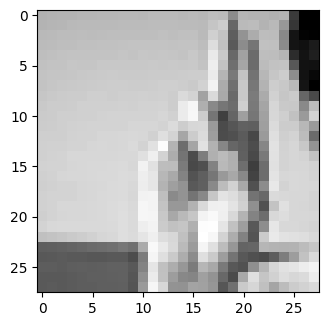

In [7]:
import random
def show_images(image):
    image = image.numpy().reshape(28,28)
    plt.figure(figsize=(8, 8))
    plt.subplot(1,2,2)
    plt.imshow(image, cmap='gray')
show_images(train_set[random.randrange(0,len(train_set))])

In [8]:
train_label = tf.convert_to_tensor(train_label)
test_label = tf.convert_to_tensor(test_label)

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((train_set, train_label))
test_ds = tf.data.Dataset.from_tensor_slices((test_set, test_label))

In [10]:
# image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1./255.0,
#     rotation_range=40,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     shear_range=0.2,
#     fill_mode='nearest'
# )

In [11]:
# train_ds = image_gen.flow(
#     x=train,
#     y=train_label,
#     batch_size=32
# )
# test_ds = image_gen.flow(
#     x=test,
#     y=test_label,
#     batch_size=32
# )

In [12]:
train_size = 0.85
final_train_ds, final_val_ds = tf.keras.utils.split_dataset(train_ds, left_size=train_size)

In [13]:
batch_size = 64
final_train_ds = final_train_ds.shuffle(round(len(train_set)*train_size)).batch(batch_size)
final_val_ds = final_val_ds.batch(batch_size)

In [14]:
aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [22]:
model = tf.keras.Sequential([])
model.add(tf.keras.Input(shape=(28,28,1)))
model.add(tf.keras.layers.Conv2D(32, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(25, activation='softmax'))

In [23]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [24]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=adam_optimizer, metrics=['accuracy'])

In [25]:
history = model.fit(final_train_ds, epochs=10, validation_data=final_val_ds, batch_size = 64)

Epoch 1/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.4512 - loss: 1.7263 - val_accuracy: 0.9046 - val_loss: 0.3522
Epoch 2/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8451 - loss: 0.4445 - val_accuracy: 0.9823 - val_loss: 0.0872
Epoch 3/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9326 - loss: 0.1950 - val_accuracy: 0.9983 - val_loss: 0.0177
Epoch 4/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9580 - loss: 0.1203 - val_accuracy: 0.9993 - val_loss: 0.0127
Epoch 5/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9714 - loss: 0.0844 - val_accuracy: 0.9995 - val_loss: 0.0033
Epoch 6/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9777 - loss: 0.0678 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 7/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9796 - loss: 0.0595 - val_accuracy: 1.0000 - val_loss: 9.5223e-04
Epoch 8/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9848 - loss: 0.0462 - va

In [19]:
#batch size 128: 97% 55s
#batch size 64: 98% 1m2s
#batch size 32: 98% 1m40s

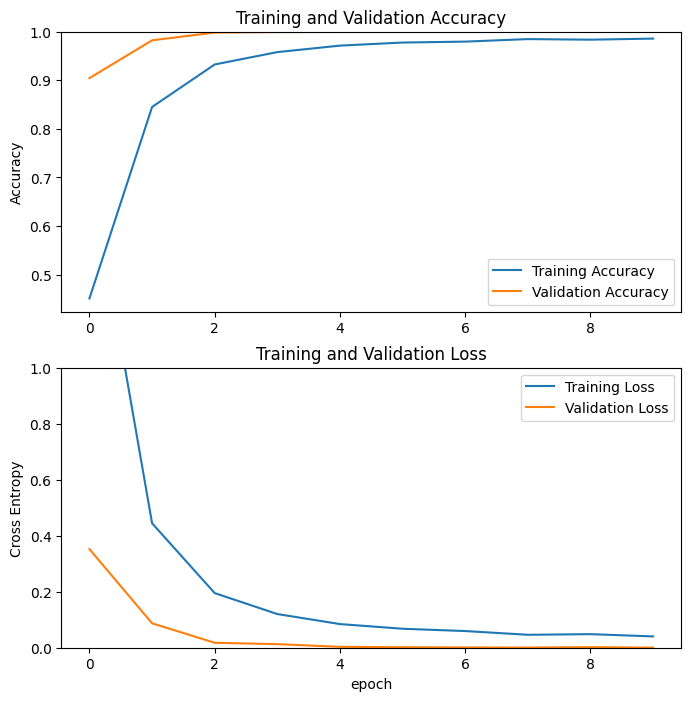

In [26]:
#Reference: https://www.tensorflow.org/tutorials/images/transfer_learning#learning_curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [27]:
prediction = model.predict(test_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [28]:
predicted_labels = []
for i in range(0,len(test)):
    predicted_labels.append(np.argmax(prediction[i]))

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
def plot_confusion_matrix(test_lab, pred_lab):
    cm = confusion_matrix(test_lab,pred_lab)
    alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
    display_cm = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=alphabet)
    #make the Confusion Matrix bigger: https://stackoverflow.com/questions/66483409/adjust-size-of-confusionmatrixdisplay-scikitlearn
    fig, ax = plt.subplots(figsize=(11,11))
    display_cm.plot(ax=ax,cmap="Blues")

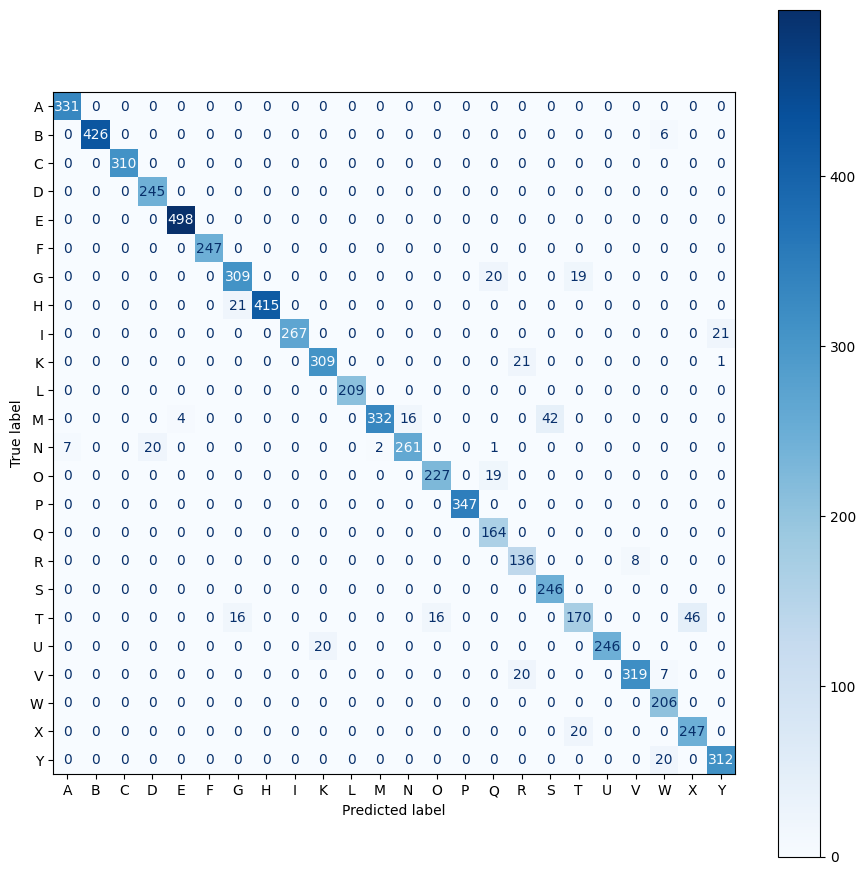

In [30]:
plot_confusion_matrix(test_label,predicted_labels)

In [31]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, classification_report

f1_score = f1_score(test_label,predicted_labels,average='weighted')
accuracy_score = accuracy_score(test_label,predicted_labels)
recall_score = recall_score(test_label,predicted_labels,average='weighted')
precision_score = precision_score(test_label,predicted_labels,average='weighted')

classification_report = classification_report(test_label,predicted_labels)

In [32]:
accuracy_score

0.9452035694366983

In [33]:
def return_alphabet(num):
    alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
    if num > 8:
        return alphabet[num-1]
    else:
        return alphabet[num]

Test Label: O
Predicted Label: O


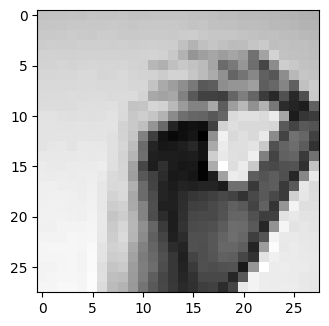

In [34]:
random_number = random.randrange(0,len(test_set))
print("Test Label:", return_alphabet(int(test_label[random_number][0])))
print("Predicted Label:", return_alphabet(predicted_labels[random_number]))
show_images(test_set[random_number])

In [35]:
vgg = tf.keras.Sequential([])
vgg.add(tf.keras.Input(shape=(28,28,1)))
#block 1
vgg.add(tf.keras.layers.Conv2D(16, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(16, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.MaxPooling2D((2,2)))
#block 2
vgg.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.MaxPooling2D((2,2)))
#block 3
vgg.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.MaxPooling2D((2,2)))
#Output
vgg.add(tf.keras.layers.Flatten())
vgg.add(tf.keras.layers.Dense(1024, activation='relu'))
vgg.add(tf.keras.layers.Dropout(0.5))
vgg.add(tf.keras.layers.Dense(512, activation='relu'))
vgg.add(tf.keras.layers.Dropout(0.3))
vgg.add(tf.keras.layers.Dense(25, activation='softmax'))

In [36]:
vgg.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,121 (4.86 MB)

 Trainable params: 1,274,121 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
vgg.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer='adam', metrics=['accuracy'])

In [38]:
vgg.fit(final_train_ds,epochs=10,validation_data=final_val_ds)

Epoch 1/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.1861 - loss: 2.6278 - val_accuracy: 0.7067 - val_loss: 0.8588
Epoch 2/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8812 - loss: 0.3405 - val_accuracy: 0.9777 - val_loss: 0.0689
Epoch 3/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9777 - loss: 0.0697 - val_accuracy: 0.9995 - val_loss: 0.0031
Epoch 4/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.9954 - val_loss: 0.0140
Epoch 5/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9908 - loss: 0.0298 - val_accuracy: 0.9964 - val_loss: 0.0118
Epoch 6/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.9920 - loss: 0.0251 - val_accuracy: 0.9964 - val_loss: 0.0122
Epoch 7/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accuracy: 0.9966 - val_loss: 0.0140
Epoch 8/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9941 - loss: 0.0195 - 

In [39]:
#batch size 32: 99.29% 2m9s
#batch size 64: 99.65% 1m36s
#batch size 128: 99.35% 1m9s

In [40]:
vgg_prediction = vgg.predict(test_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [41]:
vgg_predictions = []
for i in range(0,len(test)):
    vgg_predictions.append(np.argmax(vgg_prediction[i]))

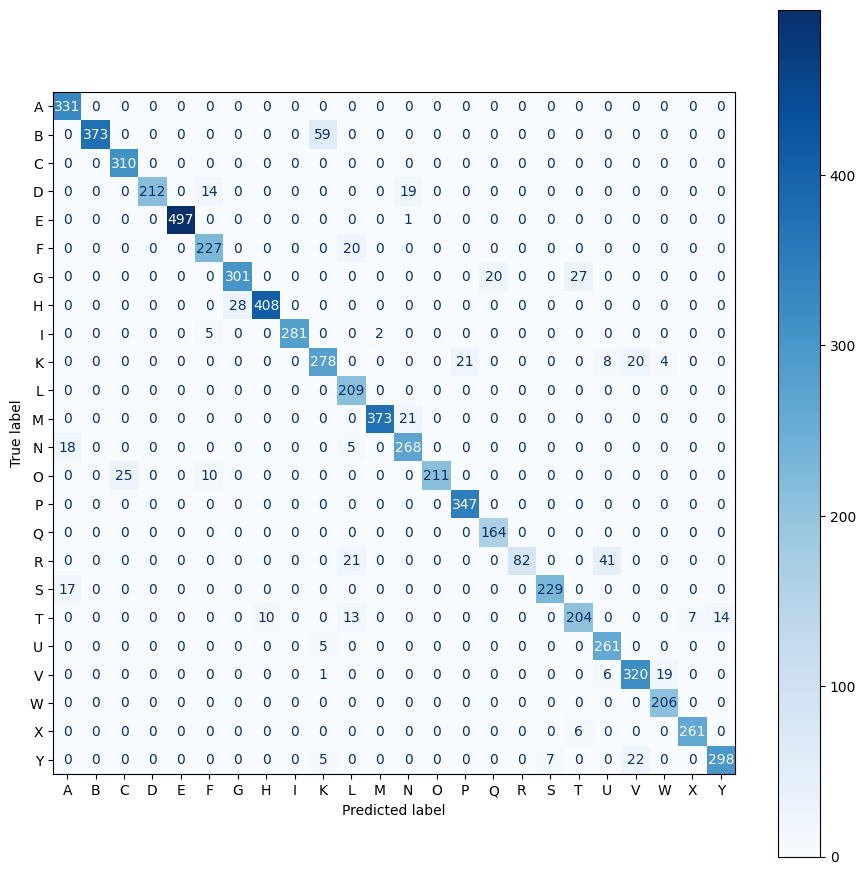

In [42]:
plot_confusion_matrix(test_label,vgg_predictions)

Test Label: O
Predicted Label: O


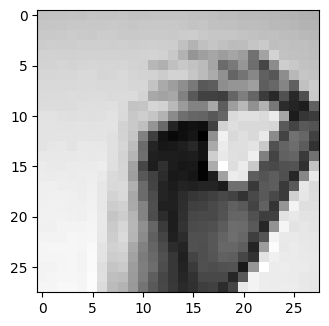

In [43]:
random_number_vgg = random.randrange(0,len(test_set))
print("Test Label:", return_alphabet(int(test_label[random_number][0])))
print("Predicted Label:", return_alphabet(vgg_predictions[random_number]))
show_images(test_set[random_number])

In [44]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, classification_report

f1_score_vgg = f1_score(test_label,vgg_predictions,average='weighted')
accuracy_score_vgg = accuracy_score(test_label,vgg_predictions)
recall_score_vgg = recall_score(test_label,vgg_predictions,average='weighted')
precision_score_vgg = precision_score(test_label,vgg_predictions,average='weighted')

classification_report = classification_report(test_label,vgg_predictions)

In [45]:
accuracy_score_vgg

0.927356385945343